# Previsão de Preços de Criptomoedas com LSTM e MiroFish

Pipeline completo para previsão de preços do Ethereum usando dados históricos da API CoinGecko.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import get_historical_data
from src.preprocessing import (
    resample_data,
    normalize_data,
    create_sequences,
    train_test_split_time_series,
)
from src.model_lstm import build_lstm_model
from src.train import train_model
from src.evaluate import evaluate_model
from src.predict import predict_future

from src.models_mirofish.mirofish_model import MiroFishModel
from src.models_mirofish.train_mirofish import train_mirofish_model
from src.models_mirofish.evaluate_mirofish import evaluate_mirofish_model

import matplotlib.pyplot as plt


## 1. Coleta dos dados


In [2]:
coin = "ethereum"
days = 120
window_size = 24

df = get_historical_data(coin=coin, days=days)
df.head()


,price
timestamp,
2026-01-01,2966.774180
2026-01-02,3000.419117
2026-01-03,3121.900672
2026-01-04,3126.041091
2026-01-05,3139.057042


## 2. Visualização inicial da série


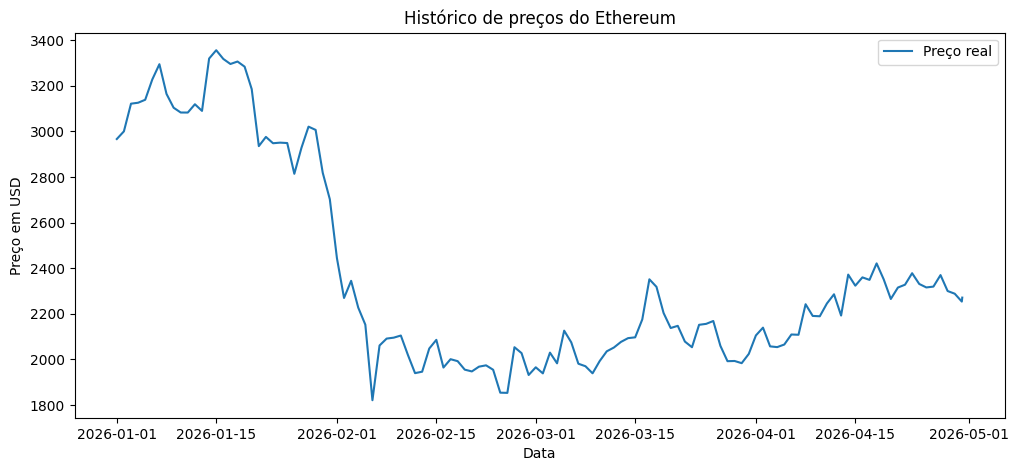

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["price"], label="Preço real")
plt.title("Histórico de preços do Ethereum")
plt.xlabel("Data")
plt.ylabel("Preço em USD")
plt.legend()
plt.show()


## 3. Pré-processamento


In [4]:
df_resampled = resample_data(df, freq="1h")

scaled, scaler = normalize_data(df_resampled)

X, y = create_sequences(scaled, window_size=window_size)

X_train, y_train, X_val, y_val, X_test, y_test = train_test_split_time_series(
    X,
    y,
    train_ratio=0.7,
    val_ratio=0.15,
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)


X_train: (1983, 24, 1)
X_val: (425, 24, 1)
X_test: (426, 24, 1)


## 4. Modelo LSTM


In [5]:
lstm_model = build_lstm_model((X_train.shape[1], X_train.shape[2]))
lstm_model.summary()


/Users/karenota/Previsao-de-Criptomoedas---LSTMs/venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Treinamento da LSTM


Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0225 - val_loss: 4.2024e-04
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0024 - val_loss: 1.4408e-04
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0022 - val_loss: 1.1021e-04
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0020 - val_loss: 1.1715e-04
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0020 - val_loss: 1.0304e-04
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0017 - val_loss: 1.9991e-04
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0018 - val_loss: 1.2504e-04
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0018 - val_loss: 9.1917e-05
Epoch 9/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0021 - val_loss: 3.3700e-04
Epoch 10/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0017 - val_loss: 7.4870e-05
Epoch 11/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0019 - val_loss: 1.1187e-04
Epoch 12/20
62/62 ━

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/plots/training_loss.png'

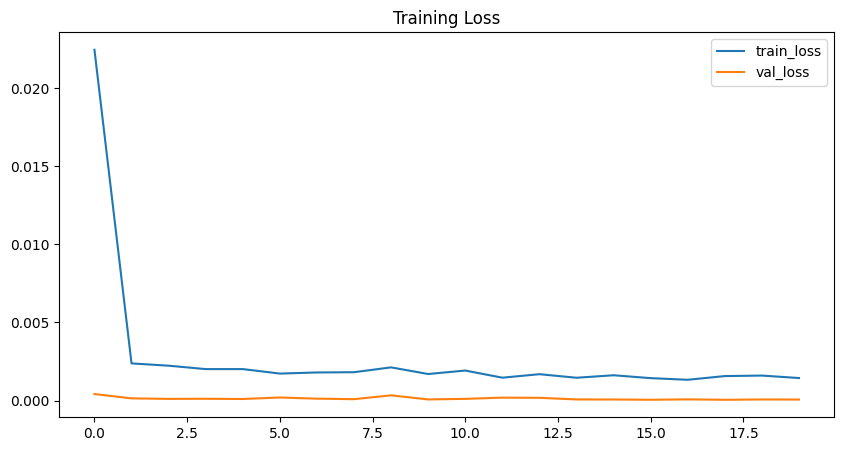

In [6]:
lstm_model, history = train_model(
    lstm_model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=20,
    batch_size=32,
)


## 6. Avaliação da LSTM


In [7]:
metrics_lstm, y_true_lstm, y_pred_lstm = evaluate_model(
    lstm_model,
    X_test,
    y_test,
    scaler,
)

metrics_lstm


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


{'MSE': 208.5324443016551,
 'RMSE': np.float64(14.440652488778168),
 'MAE': 11.08221747951921}

## 7. Modelo MiroFish em PyTorch


In [8]:
mirofish_model = MiroFishModel(input_size=1)

mirofish_model = train_mirofish_model(
    mirofish_model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=20,
    lr=0.001,
)


Epoch 1/20 | Loss: 0.180191 | Val Loss: 0.004807
Epoch 2/20 | Loss: 0.172908 | Val Loss: 0.003927
Epoch 3/20 | Loss: 0.166695 | Val Loss: 0.003390
Epoch 4/20 | Loss: 0.161453 | Val Loss: 0.003085
Epoch 5/20 | Loss: 0.156302 | Val Loss: 0.003013
Epoch 6/20 | Loss: 0.151196 | Val Loss: 0.003186
Epoch 7/20 | Loss: 0.146123 | Val Loss: 0.003634
Epoch 8/20 | Loss: 0.141725 | Val Loss: 0.004344
Epoch 9/20 | Loss: 0.137744 | Val Loss: 0.005262
Epoch 10/20 | Loss: 0.133443 | Val Loss: 0.006570
Epoch 11/20 | Loss: 0.130227 | Val Loss: 0.007909
Epoch 12/20 | Loss: 0.126801 | Val Loss: 0.009610
Epoch 13/20 | Loss: 0.122929 | Val Loss: 0.011888
Epoch 14/20 | Loss: 0.119342 | Val Loss: 0.014732
Epoch 15/20 | Loss: 0.115345 | Val Loss: 0.018649
Epoch 16/20 | Loss: 0.110935 | Val Loss: 0.024179
Epoch 17/20 | Loss: 0.106242 | Val Loss: 0.032216
Epoch 18/20 | Loss: 0.101606 | Val Loss: 0.044486
Epoch 19/20 | Loss: 0.097691 | Val Loss: 0.061624
Epoch 20/20 | Loss: 0.096735 | Val Loss: 0.078159


## 8. Avaliação do MiroFish


In [9]:
metrics_mirofish, y_true_mirofish, y_pred_mirofish = evaluate_mirofish_model(
    mirofish_model,
    X_test,
    y_test,
    scaler,
)

metrics_mirofish


{'MSE': 54154.607435549544,
 'RMSE': np.float64(232.71142523638485),
 'MAE': 229.4953821514087}

## 9. Comparação de métricas


In [10]:
print("LSTM")
print(metrics_lstm)

print("\nMiroFish")
print(metrics_mirofish)


LSTM
{'MSE': 208.5324443016551, 'RMSE': np.float64(14.440652488778168), 'MAE': 11.08221747951921}

MiroFish
{'MSE': 54154.607435549544, 'RMSE': np.float64(232.71142523638485), 'MAE': 229.4953821514087}


## 10. Gráfico comparativo


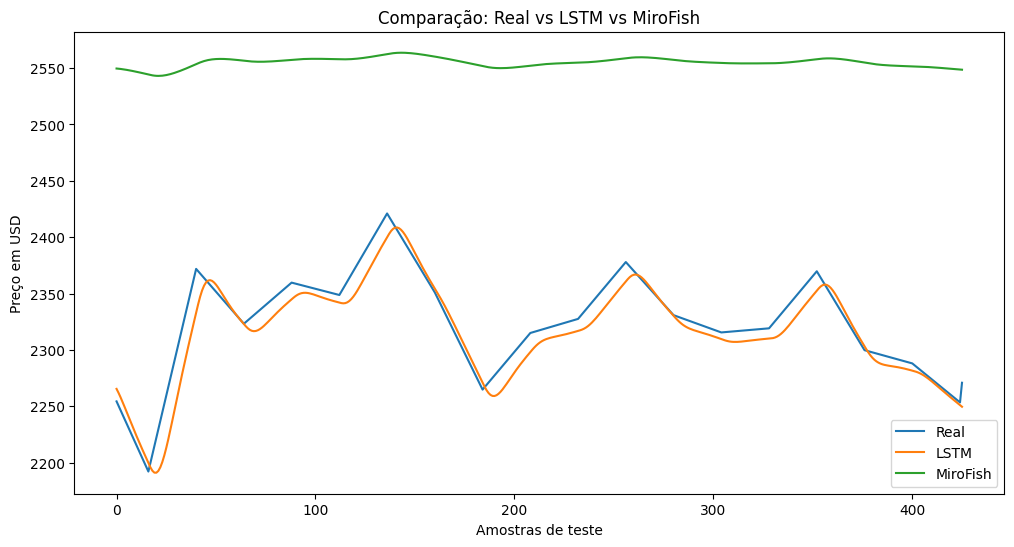

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(y_true_lstm, label="Real")
plt.plot(y_pred_lstm, label="LSTM")
plt.plot(y_pred_mirofish, label="MiroFish")
plt.title("Comparação: Real vs LSTM vs MiroFish")
plt.xlabel("Amostras de teste")
plt.ylabel("Preço em USD")
plt.legend()
plt.show()


## 11. Predição futura com LSTM


In [ ]:
future_lstm = predict_future(
    lstm_model,
    X_test[-1],
    scaler,
    steps=24,
)

plt.figure(figsize=(10, 5))
plt.plot(future_lstm, label="Previsão futura LSTM")
plt.title("Previsão futura dos próximos 24 passos")
plt.xlabel("Passo futuro")
plt.ylabel("Preço em USD")
plt.legend()
plt.show()
